# Phase 8 (stretch) — Live Paper-Trading Forward Test

The strongest available evidence against look-ahead leakage: a policy trained entirely on historical data makes a real decision on a day it had zero opportunity to have seen during development, using [Alpaca](https://alpaca.markets)'s free paper-trading API (simulated money, real market data — never real capital).

Run this notebook's decision cell once per trading day (manually, or via a scheduled task) to build up a forward-test track record over time. Every run appends one permanent, source-tagged row to `data_cache/../forward_test/decision_log_<TICKER>.csv` — it is never overwritten, so the log is the actual evidence trail.

**Setup** (see `README.md`): sign up for a free Alpaca account, generate a *Paper Trading* API key + secret, and put them in `.env` as `ALPACA_API_KEY` / `ALPACA_SECRET_KEY`.

> ## STATUS: this run's mode is determined by whether Alpaca credentials are configured
>
> - **With `ALPACA_API_KEY`/`ALPACA_SECRET_KEY` set**: fetches live market data and submits real (simulated-money) paper orders — a genuine forward-test row.
> - **Without them (this environment's default)**: every function in `scaata/live/alpaca_broker.py` falls back to a deterministic mock path, tagged `source="mock"` on every logged row — proves the harness runs end-to-end, not a real forward-test observation.
> - The frozen policy is trained **once** and persisted to disk (`data_cache/../forward_test/policy_<TICKER>.zip`); every later run loads it rather than retraining, so the model can never "see" the data it's about to decide on.
>
> See the project [README](../README.md) for the full status table across all phases.

In [1]:
import sys
sys.path.insert(0, '..')
import os

from scaata.config import FEATURE_COLUMNS
from scaata.data.loaders import load_market_data
from scaata.features.normalize import normalize_data
from scaata.live.forward_test import train_or_load_policy, run_daily_decision, read_decision_log

TICKER = 'AAPL'
SMOKE_TEST = False
PPO_TIMESTEPS = 2_000 if SMOKE_TEST else 100_000
HAS_ALPACA = bool(os.environ.get('ALPACA_API_KEY')) and bool(os.environ.get('ALPACA_SECRET_KEY'))
print(f"SMOKE_TEST={SMOKE_TEST} | ppo_timesteps={PPO_TIMESTEPS} | Alpaca credentials configured: {HAS_ALPACA} " f"{'(live paper-trading mode)' if HAS_ALPACA else '(mock fallback -- harness-only run)'}")

SMOKE_TEST=False | ppo_timesteps=100000 | Alpaca credentials configured: True (live paper-trading mode)


## 1. Train (once) or load the frozen policy

In [2]:
raw_df = load_market_data([TICKER], '2020-01-01', '2024-01-01', use_cache=True)
from scaata.features.technical import add_features
featured_df = add_features(raw_df)
train_norm, _, _, _ = normalize_data(featured_df, featured_df, FEATURE_COLUMNS)

model = train_or_load_policy(TICKER, train_norm, FEATURE_COLUMNS, seed=0, total_timesteps=PPO_TIMESTEPS)
print(f"Policy ready for {TICKER} (trained fresh if this is the first run, loaded from disk otherwise).")

Policy ready for AAPL (trained fresh if this is the first run, loaded from disk otherwise).


## 2. Run today's decision

Re-running this cell on the same day is safe (it just appends another row) but is only meaningful once per trading day in a real deployment.

In [3]:
row = run_daily_decision(TICKER, model, FEATURE_COLUMNS, qty=1.0)
for k, v in row.items():
    print(f"  {k}: {v}")

Already placed a live decision for AAPL today (2026-07-22T04:18:15.118091+00:00, action=sell) -- returning that instead of submitting a duplicate order. Re-run after the next US market day begins for a new one.
  timestamp_utc: 2026-07-22T04:18:15.118091+00:00
  ticker: AAPL
  action: sell
  close_price: 327.66
  order_id: 3241c8a0-c7cb-4faa-b7da-daa612a9c18a
  order_status: OrderStatus.ACCEPTED
  account_equity: 100000.0
  data_source: live
  order_source: live
  account_source: live
  overall_source: live


## 3. The accumulated forward-test log

This grows by one row every time the decision cell above runs on a new day. The `overall_source` column is what separates real forward-test evidence from harness smoke-testing -- filter to `overall_source == "live"` before treating any of this as a real result.

In [4]:
log = read_decision_log(TICKER)
print(f"{len(log)} logged decision(s) so far for {TICKER}.")
print(log.tail(10).to_string(index=False))

if (log['overall_source'] == 'live').sum() == 0:
    print("\nNote: no live-sourced rows yet -- every row above is a mock/harness run, not real forward-test evidence.")

3 logged decision(s) so far for AAPL.
                   timestamp_utc ticker action  close_price                             order_id                   order_status  account_equity data_source order_source account_source overall_source
2026-07-22T03:34:12.143100+00:00   AAPL   sell    327.73999                           mock-order accepted (mock, not submitted)         10000.0        mock         mock           mock           mock
2026-07-22T03:59:42.402845+00:00   AAPL   sell    327.66000 87904a3d-a321-4655-a520-420343b99af2           OrderStatus.ACCEPTED        100000.0        live         live           live           live
2026-07-22T04:18:15.118091+00:00   AAPL   sell    327.66000 3241c8a0-c7cb-4faa-b7da-daa612a9c18a           OrderStatus.ACCEPTED        100000.0        live         live           live           live


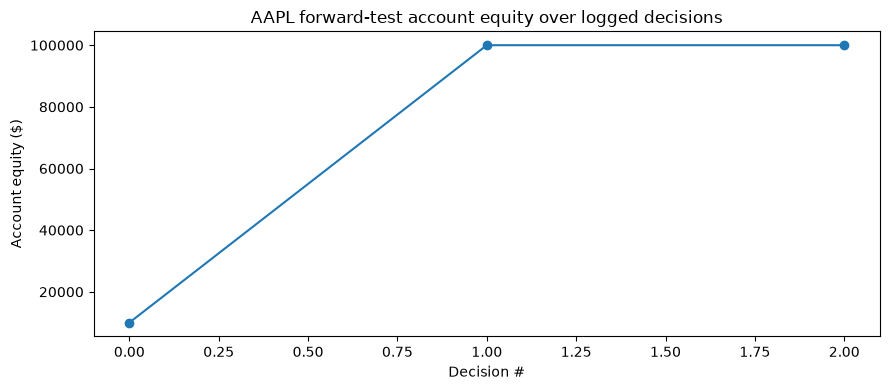

In [5]:
import matplotlib.pyplot as plt

if len(log) > 1:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(len(log)), log['account_equity'], marker='o')
    ax.set_title(f'{TICKER} forward-test account equity over logged decisions')
    ax.set_xlabel('Decision #')
    ax.set_ylabel('Account equity ($)')
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 logged decisions for an equity-over-time plot -- run the decision cell again on a later day.")

## Done criteria for this phase
- The policy is trained once and frozen to disk -- never retrained on data it is about to decide on (verified above and by `tests/test_forward_test.py`).
- Every logged row is source-tagged `live`/`mock`, so a harness smoke-test can never be mistaken for real forward-test evidence (`tests/test_alpaca_broker.py`, `tests/test_forward_test.py`).
- The log is append-only and persists across kernel restarts and days -- it is the actual evidence trail, not a single-run printout.
- This notebook only ever targets Alpaca's *paper* environment; there is no code path anywhere in `scaata/live/` that can place a real order with real capital.